> **@paxton** these were run outside the Docker container (Docker would not start locally), against
> a copy of `analysis_helpers` with `DATA_DIR` repointed at the repo --- i.e. what the bind-mount does,
> with the notebook itself unmodified. Worth re-running in the container to confirm.

# Does the episode's own shape predict what participants leave out of it?

`rdp-analyses.ipynb` shows that the events a participant's immediate recall trajectory could most
afford to lose are the events they go on to drop across the delay. This notebook applies the same
measure one step earlier in the chain, to the episode itself: are the events the *episode's*
trajectory could most afford to lose the events that fewest participants describe?

The measure is the same one used there. Each event's **prominence** is the tolerance at which
simplification first removes it, swept rather than selected, so nothing about what participants
recalled enters its construction. The episode's first and last events are excluded, since
simplification never removes the endpoints of a trajectory.

An earlier version of this notebook asked the question a different way, by simplifying the episode
at the tolerance that best aligned it to each participant's immediate recall and testing the removed
set against a hypergeometric null. That version selected the tolerance against the very recall whose
omissions it then predicted, and it did not survive a null matched on that selection. It has been
replaced here by the threshold-free measure rather than kept, since the two are answering the same
question and only one of them is answering it fairly.

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import spearmanr

from analysis_helpers import Episode, Participant
from analysis_helpers.functions import (
    bootstrap_ci,
    events_recounted,
    mean_center,
    removal_thresholds,
    show_source
)

## Functions

Both live in `analysis_helpers.functions`, and are the same ones
`rdp-analyses.ipynb` uses.

In [2]:
show_source(removal_thresholds)

In [3]:
show_source(events_recounted)

## Load data

In [4]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()
n_events = len(atlep1.events)

# simplification never removes a trajectory's endpoints, so the first and last
# episode events can carry no prominence and are excluded throughout
INTERIOR = np.arange(1, n_events - 1)

# the same tolerance grid rdp-analyses.ipynb sweeps
EPSILONS = np.arange(0, 2, 0.01).round(2)

print(f'{len(participants)} participants, {n_events} episode events '
      f'({len(INTERIOR)} after excluding the endpoints)')

53 participants, 20 episode events (18 after excluding the endpoints)


## Prominence against how many participants described each event

The episode trajectory is mean-centered, as everywhere else in the paper. If the episode's geometry
governed what people take from it, the events it could most afford to lose --- those removed at the
lowest tolerances --- should be the events fewest participants described.

Spearman rather than Pearson, since prominence is a threshold on a swept grid and its spacing is not
meaningful, and two-sided, since nothing about the geometry guarantees a direction. n here is the
number of **episode events**, not the number of participants.

In [5]:
prominence = removal_thresholds(mean_center(atlep1.events), EPSILONS)

described = np.array(
    [events_recounted(p.event_matches['atlep1'], n_events) for p in participants]
).mean(axis=0)

rho, p = spearmanr(prominence[INTERIOR], described[INTERIOR])
ci_lo, ci_hi = bootstrap_ci(
    np.column_stack([prominence[INTERIOR], described[INTERIOR]]),
    lambda pairs: spearmanr(pairs[:, 0], pairs[:, 1]).statistic
)

print(f'prominence vs proportion describing: rho={rho.item():.3f}, p={p.item():.4f}, '
      f'95% CI [{ci_lo:.3f}, {ci_hi:.3f}], n={len(INTERIOR)} episode events')

prominence vs proportion describing: rho=0.215, p=0.3910, 95% CI [-0.316, 0.688], n=18 episode events


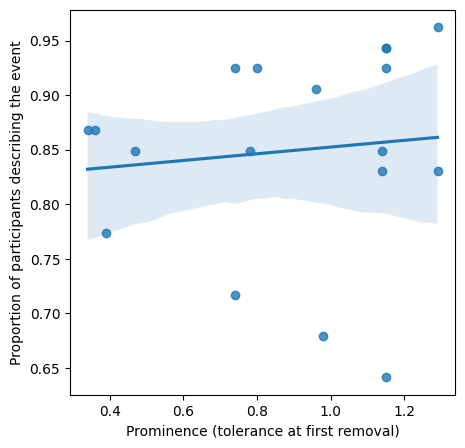

In [6]:
fig, ax = plt.subplots(1, figsize=(5, 5))
sns.regplot(x=prominence[INTERIOR], y=described[INTERIOR], ax=ax)
ax.set_xlabel('Prominence (tolerance at first removal)')
ax.set_ylabel('Proportion of participants describing the event')
ax.set_box_aspect(1)
plt.show()

## What survives

It does not hold. The relationship runs in the predicted direction but is nowhere near reliable, and
the interval on it spans zero comfortably.

With 18 events to work with, this test is far weaker than its counterpart in `rdp-analyses.ipynb`,
which has 53 participants and asks the question within each of them. So this is a failure to
demonstrate rather than a demonstrated absence. What can be said is that the compression we can
measure between two recountings has no counterpart, at this resolution, between the episode and the
recountings of it.